In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

# Visualise and listen to data going into the models

In [2]:
from nanodrz.data import gather_speakers_from_folder, artificial_diarisation_sample
from nanodrz import data
from nanodrz.utils import play, visualise_annotation

In [5]:
speakers = data.librilight_small()
print(speakers)
for s in speakers:
    # Convert paths to denoised
    for i in range(len(s.utts)):
        i, f = s.utts[i]
        fsplit = f.split("/")
        fsplit[-1] = fsplit[-1].replace(".flac", "_d.wav")
        f = "/".join(fsplit)
        s.utts[i] = i, f

[1649, 32, 3366, 246, 3470, 3367, 198, 4020, 2182, 3821, 5423, 813, 1251, 3511, 3211, 2687, 3521, 12536, 250, 2206, 809, 2553, 3368, 3398, 1323, 575, 1948, 5435, 103, 3887, 4009, 6548, 1160, 3330, 2448, 7208, 47, 75, 505, 447, 1867, 1478, 1514, 112, 2196, 3744, 868, 840, 4218, 20, 1472, 1316, 2368, 64, 5118, 2775, 2262, 3771, 2197, 842, 3483, 7009, 2544, 147, 4217, 4519, 487, 5192, 1943, 6246, 3775, 4321, 510, 4358, 4214, 2283, 2911, 1259, 153, 543, 1433, 3840, 1944, 4362, 177, 4229, 279, 163, 126, 78, 150, 123, 5436, 3860, 31, 3088, 3098, 1870, 3076, 2294, 3952, 4191, 2144, 3718, 2812, 462, 1212, 622, 3546, 949, 4338, 296, 28, 3845, 4211, 1868, 1557, 254, 2351, 12539, 2074, 472, 1286, 1905, 1280, 3681, 7079, 1497, 816, 3032, 82, 1264, 2996, 1554, 3389, 263, 1548, 3327, 1614, 36, 3296, 2784, 1085, 2137, 613, 205, 1195, 2724, 89, 3990, 3864, 1492, 1060, 2733, 3657, 1331, 3609, 1401, 1066, 3316, 26, 2214, 2333, 4115, 3114, 2405, 2234, 439, 2495, 204, 1961, 3292, 1127, 1724, 2800, 1368, 3

Failed to open the input "/home/harry/.cache/nanodrz/chunks/tiger_blake_mjk_64kb_11_d.wav" (No such file or directory).
Exception raised from get_input_format_context at /__w/audio/audio/pytorch/audio/src/libtorio/ffmpeg/stream_reader/stream_reader.cpp:42 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::string) + 0x57 (0x7f9f36381d87 in /home/harry/nanodrz/.venv/lib/python3.11/site-packages/torch/lib/libc10.so)
frame #1: c10::detail::torchCheckFail(char const*, char const*, unsigned int, std::string const&) + 0x64 (0x7f9f3633275f in /home/harry/nanodrz/.venv/lib/python3.11/site-packages/torch/lib/libc10.so)
frame #2: <unknown function> + 0x42904 (0x7f9f3628d904 in /home/harry/nanodrz/.venv/lib/python3.11/site-packages/torio/lib/libtorio_ffmpeg4.so)
frame #3: torio::io::StreamingMediaDecoder::StreamingMediaDecoder(std::string const&, std::optional<std::string> const&, std::optional<std::map<std::string, std::string, std::less<std::string>, std::allocator<s

/home/harry/nanodrz/.venv/lib/python3.11/site-packages/pyannote/core/notebook.py:181: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(self.crop)


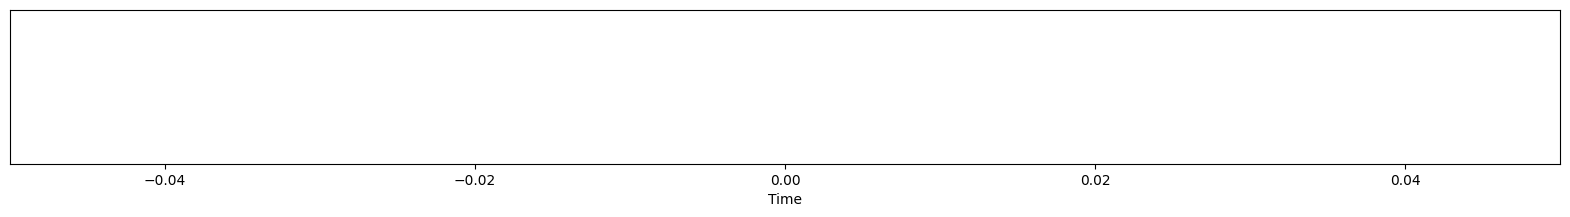

AssertionError: play() needs a non empty audio array

In [6]:
for i in range(3):
    audio, labels = data.artificial_diarisation_sample(list(speakers), min_secs=15, max_secs=45, num_speakers=2, silence_max=2, interrupt_max=2)
    print(audio.shape[-1]/16000)
    visualise_annotation(labels)
    play(audio, 16000)